# 每个玩家名字的胜率统计

本 notebook 从 `logs/session_*/game_complete.json` 统计“每个玩家名字（例如 Derek）”的胜率：

- **Camp Win Rate**：该名字在该局所属阵营是否获胜
- 可选输出：该名字在该局扮演的角色分布（Seer/Doctor/Villager/Werewolf）

> 在你当前匿名设定下，显示名字会映射到固定 8 个名字，本统计按显示名字聚合。

In [98]:
from __future__ import annotations

import json
import math
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def project_root() -> Path:
    cwd = Path.cwd()
    if (cwd / "logs").is_dir():
        return cwd
    if (cwd.parent / "logs").is_dir():
        return cwd.parent
    return cwd


ROOT = project_root()
LOGS_DIR = ROOT / "logs"

ROLE_TO_CAMP = {
    "Villager": "Villagers",
    "Seer": "Villagers",
    "Doctor": "Villagers",
    "Werewolf": "Werewolves",
}

In [99]:
def iter_complete_games(logs_dir: Path):
    for d in sorted(logs_dir.glob("session_*")):
        if not d.is_dir():
            continue
        fp = d / "game_complete.json"
        if fp.is_file():
            yield fp


def extract_role_players(data: dict) -> list[tuple[str, str, str]]:
    """返回 [(internal_name, role, display_name), ...]"""
    pairs: list[tuple[str, str, str]] = []

    def add_player(p: dict, role: str):
        n = p.get("name")
        if not n:
            return
        n = str(n)
        m = p.get("name_to_display") or {}
        display = str(m.get(n, n))
        pairs.append((n, role, display))

    seer = data.get("seer") or {}
    add_player(seer, "Seer")

    doctor = data.get("doctor") or {}
    add_player(doctor, "Doctor")

    for v in data.get("villagers") or []:
        add_player(v, "Villager")

    for w in data.get("werewolves") or []:
        add_player(w, "Werewolf")

    return pairs


def wilson_ci(successes: int, total: int, z: float = 1.96) -> tuple[float, float]:
    """Wilson score interval for binomial proportion (returns [low, high] in [0, 1])."""
    if total <= 0:
        return 0.0, 0.0

    p_hat = successes / total
    denom = 1.0 + (z * z) / total
    center = (p_hat + (z * z) / (2.0 * total)) / denom
    margin = (z / denom) * math.sqrt((p_hat * (1.0 - p_hat) / total) + (z * z) / (4.0 * total * total))
    low = max(0.0, center - margin)
    high = min(1.0, center + margin)
    return low, high


def collect_player_stats(logs_dir: Path):
    total = defaultdict(int)
    camp_win = defaultdict(int)
    role_counts = defaultdict(lambda: defaultdict(int))

    game_count = 0

    for fp in iter_complete_games(logs_dir):
        try:
            data = json.loads(fp.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            continue

        winner = str(data.get("winner", "")).strip()
        if winner not in {"Villagers", "Werewolves"}:
            continue

        role_players = extract_role_players(data)
        if not role_players:
            continue

        game_count += 1

        for _, role, display_name in role_players:
            total[display_name] += 1
            role_counts[display_name][role] += 1
            if ROLE_TO_CAMP.get(role) == winner:
                camp_win[display_name] += 1

    rows = []
    for player_name in sorted(total.keys()):
        t = total[player_name]
        cw = camp_win[player_name]
        role_dist = dict(sorted(role_counts[player_name].items()))
        win_rate = (100.0 * cw / t) if t else 0.0
        ci_low, ci_high = wilson_ci(cw, t)

        rows.append(
            {
                "Player": player_name,
                "Samples": t,
                "CampWins": cw,
                "CampWinRate(%)": win_rate,
                "CI95_Low(%)": 100.0 * ci_low,
                "CI95_High(%)": 100.0 * ci_high,
                "RoleDist": role_dist,
            }
        )

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(by=["CampWinRate(%)", "Player"], ascending=[False, True]).reset_index(drop=True)
    return df, game_count

In [100]:
df, n_games = collect_player_stats(LOGS_DIR)

print(f"Logs directory: {LOGS_DIR.resolve()}")
print(f"Completed games used: {n_games}")

if not df.empty:
    display(df[["Player", "Samples", "CampWins", "CampWinRate(%)", "CI95_Low(%)", "CI95_High(%)", "RoleDist"]])
else:
    print("No completed games found.")

Logs directory: D:\Github_Clone\werewolf_arena\logs
Completed games used: 25


,Player,Samples,CampWins,CampWinRate(%),RoleDist
0,Cherry,25,18,72.0,"{'Doctor': 5, 'Seer': 4, 'Villager': 12, 'Were..."
1,Apple,25,16,64.0,"{'Doctor': 2, 'Seer': 1, 'Villager': 16, 'Were..."
2,Grape,25,15,60.0,"{'Doctor': 3, 'Seer': 3, 'Villager': 10, 'Were..."
3,Banana,25,14,56.0,"{'Seer': 4, 'Villager': 15, 'Werewolf': 6}"
4,Kiwi,25,14,56.0,"{'Doctor': 1, 'Seer': 4, 'Villager': 12, 'Were..."
5,Plum,25,14,56.0,"{'Doctor': 3, 'Seer': 4, 'Villager': 10, 'Were..."
6,Peach,25,13,52.0,"{'Doctor': 8, 'Seer': 2, 'Villager': 12, 'Were..."
7,Mango,25,10,40.0,"{'Doctor': 3, 'Seer': 3, 'Villager': 13, 'Were..."


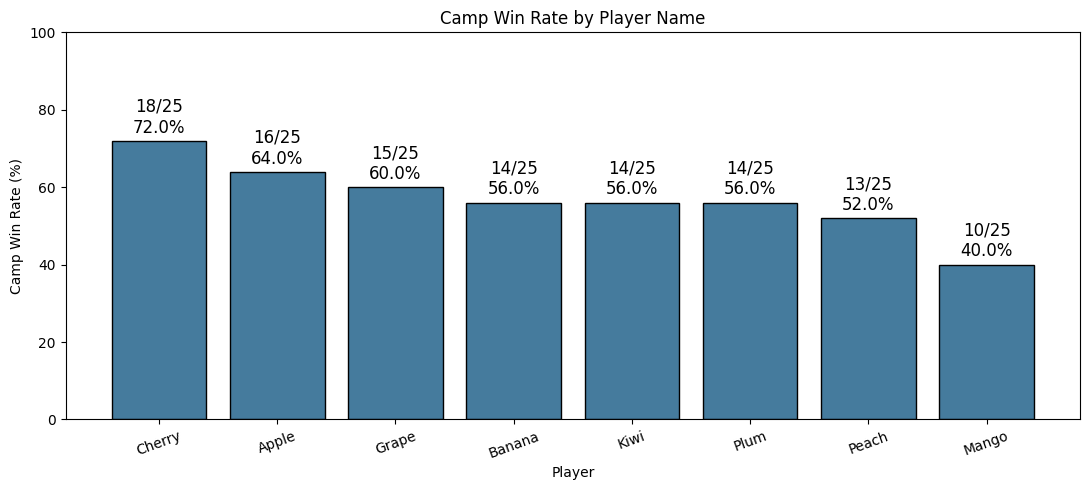

In [101]:
if not df.empty and df["Samples"].sum() > 0:
    plot_df = df.sort_values(by="CampWinRate(%)", ascending=False).reset_index(drop=True)

    y = plot_df["CampWinRate(%)"]
    yerr_low = y - plot_df["CI95_Low(%)"]
    yerr_high = plot_df["CI95_High(%)"] - y

    plt.figure(figsize=(11, 5))
    bars = plt.bar(
        plot_df["Player"],
        y,
        color="#457b9d",
        edgecolor="black",
    )
    plt.errorbar(
        x=plot_df["Player"],
        y=y,
        yerr=[yerr_low, yerr_high],
        fmt="none",
        ecolor="black",
        elinewidth=1.2,
        capsize=4,
    )

    plt.ylim(0, 100)
    plt.ylabel("Camp Win Rate (%)")
    plt.xlabel("Player Codename")
    plt.title("Camp Win Rate by Player Codename (95% Wilson CI)")
    plt.xticks(rotation=20)

    for i, b in enumerate(bars):
        h = b.get_height()
        lo = plot_df.iloc[i]["CI95_Low(%)"]
        hi = plot_df.iloc[i]["CI95_High(%)"]
        plt.annotate(
            f"{plot_df.iloc[i]['CampWins']}/{plot_df.iloc[i]['Samples']}\n{h:.1f}% [{lo:.1f}, {hi:.1f}]",
            xy=(b.get_x() + b.get_width() / 2, h),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()